In [1]:
from dotenv import load_dotenv

load_dotenv()

%load_ext mypy_ipython

In [4]:
from langgraph.graph import START, END, StateGraph, add_messages
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage
from collections.abc import Sequence
from typing import Literal, Annotated

In [5]:
my_list = add_messages(
    [
        HumanMessage(content="Hello!"),
        AIMessage(content="Hi there! How can I help you today?"),
    ],
    [
        HumanMessage(content="What's the weather like today?"),
    ],
)

In [6]:
my_list

[HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='e87481b4-9047-446f-98dc-a1e2722ef620'),
 AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={}, id='452d9a4f-73d4-4988-bfa2-563322fa7110'),
 HumanMessage(content="What's the weather like today?", additional_kwargs={}, response_metadata={}, id='ca3e2e15-9082-4ce3-9da1-f5af2e659e37')]

In [7]:
class State(TypedDict):
    messages: Annotated[
        Sequence[BaseMessage],
        add_messages,
    ]

In [8]:
chat = ChatOpenAI(
    model="gpt-4.1-mini", temperature=0, seed=42, max_completion_tokens=100
)

In [12]:
def ask_question(state: State) -> State:
    print(f"\n----> Entered ask_question:")
    for msg in state["messages"]:
        msg.pretty_print()

    question = "What is your question?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(content=input())])

In [14]:
def chatbot(state: State) -> State:
    print(f"\n----> Entering chatbot:")
    for msg in state["messages"]:
        msg.pretty_print()

    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages=[response])

In [33]:
def ask_another_question(state: State) -> State:
    print(f"\n----> Entered ask_another_question:")
    for msg in state["messages"]:
        msg.pretty_print()

    question = "What is your next question? (yes/no)"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(content=input())])

In [34]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:
    if state["messages"][-1].content.lower() in ["yes", "y"]:
        return "ask_question"
    else:
        return "__end__"

In [35]:
graph = StateGraph(State)

In [36]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function,
    path_map={"ask_question": "ask_question", "__end__": END},
)

In [37]:
graph_compiled = graph.compile()

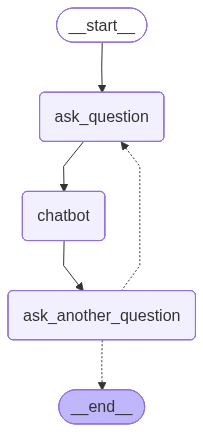

In [20]:
graph_compiled

In [38]:
graph_compiled.invoke(State(messages=[]))


----> Entered ask_question:
What is your question?

----> Entering chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

when did the liberty statue arise?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886. It was a gift from France to the United States and symbolizes freedom and democracy. If you meant a different "Liberty Statue," please let me know!

----> Entered ask_another_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

when did the liberty statue arise?
================================== Ai Message ==================================

The Statue of Liberty was dedicated on October 28, 1886. It was a gift fr

{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='5bf231af-e08d-44b8-878d-44904aa9e67e'),
  HumanMessage(content='when did the liberty statue arise?', additional_kwargs={}, response_metadata={}, id='c78a1890-703d-447a-98be-762ec15eb86e'),
  AIMessage(content='The Statue of Liberty was dedicated on October 28, 1886. It was a gift from France to the United States and symbolizes freedom and democracy. If you meant a different "Liberty Statue," please let me know!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 23, 'total_tokens': 69, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_376a7ccef1', 'id': 'chatcmpl-CsvqWfxx0JMUroCEjgysF2lonGLLF', 'serv